### Research course submission

**Name:** Abhijith Babu

**Paper:** Integrated Decision Gradients: Compute Your Attributions Where the Model Makes Its Decision

# Integrated Decision gradients

Integrated gradients are attribution methods used to find the attribution of an input feature to the output of the model. Integrated gradients are one of the fewest algorithms that follows all the axioms. However they face one drawback.

The straightline between the input and baseline are interpolated uniformly and their gradients are integrated. But the model's decision making varies along this path.

### Contributions of this paper

This paper does the following two contributions

- In an interpolated image in the straightline, the gradients are scaled with an importance factor (gradient of the model with respect to the line)

- In the reimann's approximation of integration, instead of choosing uniform decision points, we choose more points from the part of the line which is more important using an adaptive sampling algorithm

In [1]:
# importing required libraries

import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import os
import contextlib
from tqdm import tqdm
import matplotlib.pyplot as plt
import requests

In [ ]:
# Loading the vgg19 model

model = models.vgg19(pretrained=True)
with open(os.devnull, 'w') as fnull:
    with contextlib.redirect_stdout(fnull):
        model.eval()

C:\Users\abhij\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\abhij\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
# Three images chosen for demonstration. The images are scaled to 224*224 for better performance

images = [
    ["images/img1.jpg"],
    ["images/img2.jpg"],
    ["images/img3.jpg"]
]

image_size = 224

In [4]:
# function to load and transform the image

def load_image(im):
    path = im[0]
    image = Image.open(path)
    transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor()
    ])
    image = transform(image)
    image = image.unsqueeze(0)
    return image

In [5]:
# function to get the class of the image from the model

def prediction(model, img):
    with torch.no_grad():
        pred = model(img)
    return torch.argmax(pred,dim=1).item()

In [ ]:
# imagenet classes list

url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
response = requests.get(url)
classes_list = response.text.strip().split("\n")

In [7]:
def get_name(cls):
    return classes_list[cls]

### Visualizing the interpolation

Here I am choosing 10 images between the input and the baseline and plotting their gradients to see how the model learns at each point in the line.

We can see how the class score (S) changes rapidly in certain parts of the line

predicted class:  tick


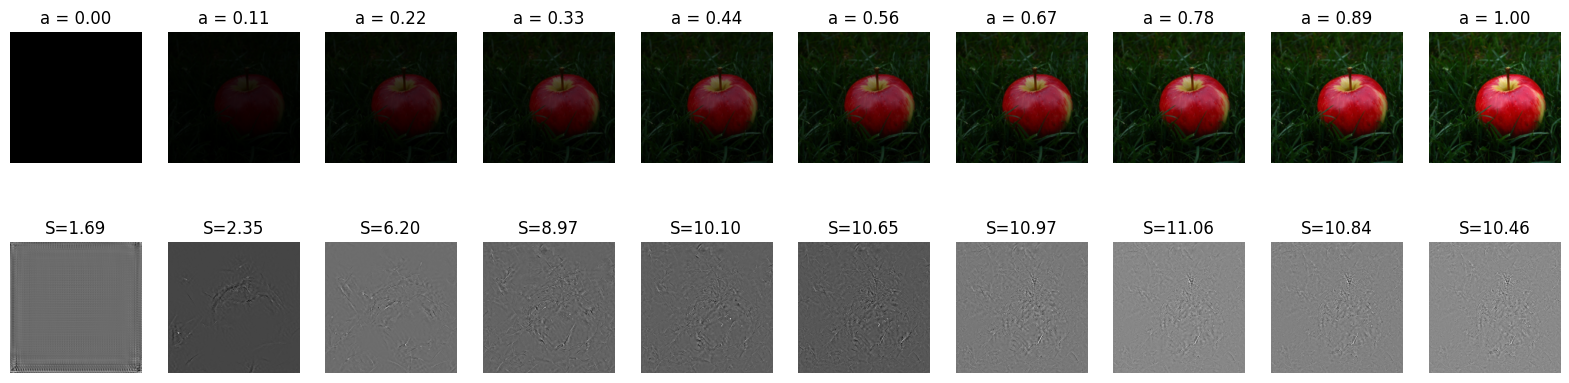

predicted class:  bustard


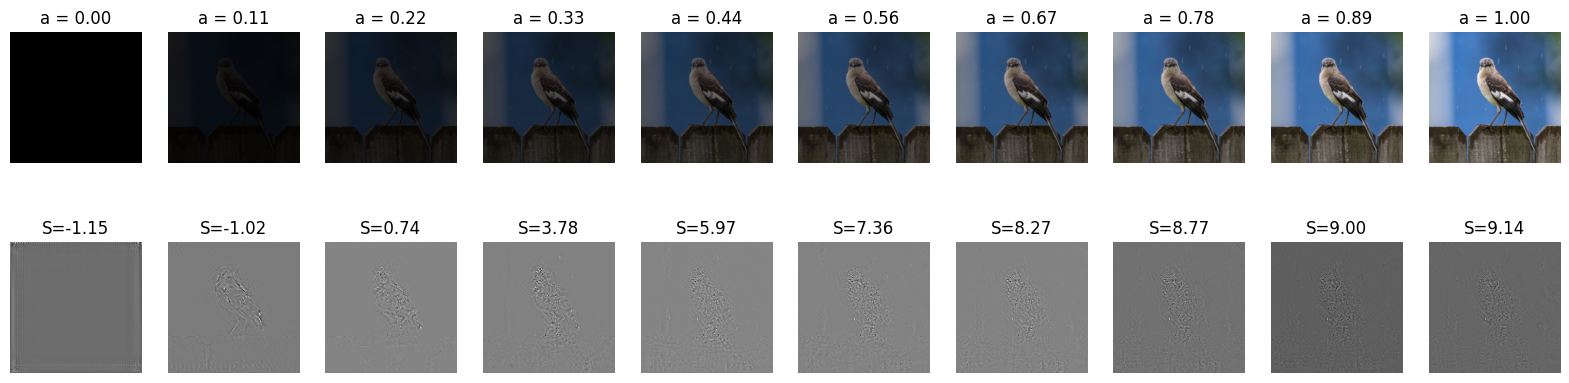

predicted class:  hen


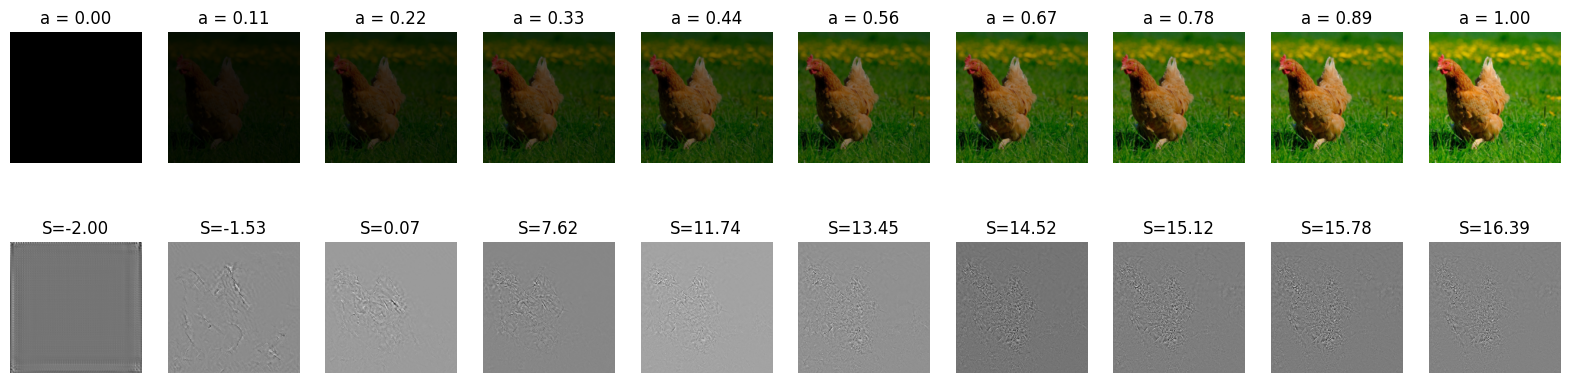

In [ ]:
# Visualizing the interpolation of the image from the base image

for i in range(len(images)):
    image = load_image(images[i])
    prediction_class = prediction(model, image)
    print("predicted class: ", get_name(prediction_class))

    base_image = 0*image 

    steps = 9

    plt.figure(figsize=(20, 5))
    for i in range(steps+1):
        alpha = i/steps
        new_image = base_image + (image - base_image) * alpha
        new_image = new_image.requires_grad_()
        new_image.retain_grad()
        class_scores = model(new_image)
        target_score = class_scores[0, prediction_class]
        model.zero_grad()
        target_score.backward(retain_graph=True)
        gradients = new_image.grad.data.mean(dim=0).mean(dim=0)

        grads = np.array(gradients.detach().numpy(), dtype=np.float32)
        grads = ((grads - np.min(grads))*255) / (np.max(grads) - np.min(grads))
        grads = np.array(grads, dtype=np.uint8)
        
        grad_image = Image.fromarray(grads)        

        # printing the image at each step
        plt.subplot(2, steps+1, i+1)
        plt.imshow(new_image[0].permute(1, 2, 0).detach().numpy())
        plt.axis('off')
        plt.title(f"a = {alpha:.2f}")

        # printing the gradients at each step

        plt.subplot(2, steps+1, i+steps+2)
        plt.imshow(grad_image, cmap='gray')
        plt.axis('off')
        plt.title(f"S={target_score:.2f}")

    plt.show()


### Computing the Integrated decision gradients.

Two components of the integrated gradients are calculating the gradient of the model with respect to the image, and with the line (alpha).

To calculate gradients w.r.t. image, we can backpropagate the class score through the image. But this is not possible through the line. So the gradient w.r.t. the line is calculated by making a small movement (alpha = 0.001) through the line and finding the rate of change of class score with respect to that change. Thus I was able to find the importance_factor

Image:  tick


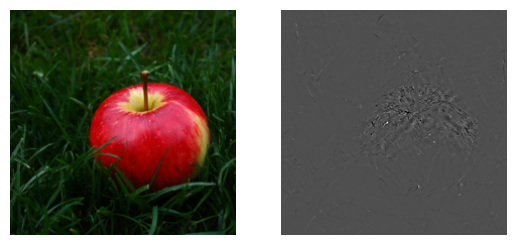

Image:  bustard


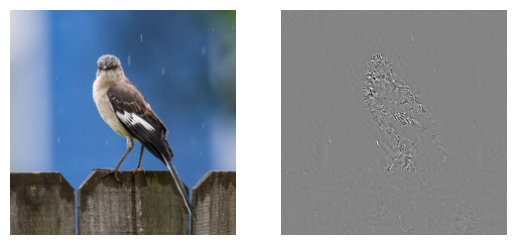

Image:  hen


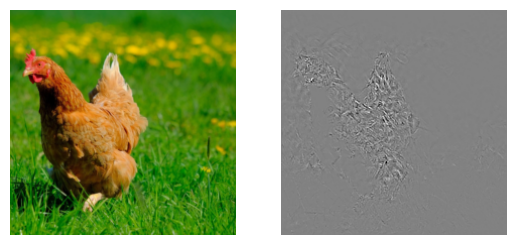

In [9]:
# computing IDG
for img in images:
    image = load_image(img)
    prediction_class = prediction(model, image)
    print("Image: ", get_name(prediction_class))
    base_image = 0*image 
    class_score_base = model(base_image)[0, prediction_class]
    class_score_image = model(image)[0, prediction_class]
    steps = 10
    samples =[0]
    class_score_old_image = class_score_base
    for i in range(steps):
        new_image = base_image + (image-base_image) * i/steps
        class_score_new_image = model(new_image)[0, prediction_class]
        score_ratio = ((class_score_new_image - class_score_old_image) / (class_score_image - class_score_base)).detach().cpu().numpy()
        sample_value = np.round(score_ratio * steps)
        samples.append(sample_value.item())
        class_score_old_image = class_score_new_image
    
    alpha_list = []

    for i in range(steps):
        for j in range(int(samples[i])):
            alpha = (i/steps) + (j/(steps*samples[i]))
            alpha_list.append(alpha)

    # print(alpha_list)
    idg = np.zeros((image_size, image_size))
    for i in alpha_list:
        interpolated_image = base_image + (image - base_image) * i
        interpolated_image = interpolated_image.requires_grad_()
        interpolated_image.retain_grad()
        class_scores = model(interpolated_image)
        target_score = class_scores[0, prediction_class]
        model.zero_grad()
        target_score.backward(retain_graph=True)
        gradients = interpolated_image.grad.data.mean(dim=0).mean(dim=0)
        temp_alpha = i + 0.001
        temp_image = base_image + (image - base_image) * temp_alpha
        class_scores_temp = model(temp_image)
        target_score_temp = class_scores_temp[0, prediction_class]
        importance_factor = float((target_score_temp - target_score)/0.001)
        gradients = gradients * importance_factor
        idg += gradients.detach().cpu().numpy()
    idg = np.array(idg, dtype=np.float32)
    idg = (idg*image.mean(dim=0).mean(dim=0).detach().numpy())/steps
    idg = ((idg - np.min(idg))*255) / (np.max(idg) - np.min(idg))

    plt.subplot(1, 2, 1)
    plt.imshow(image[0].permute(1, 2, 0).detach().numpy())
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(idg, cmap='gray')
    plt.axis('off')
    # plt.title(f"IG-{alpha:.2f}")
    plt.show()



